# Continuous Sign Language Recognition on PHOENIX-2014

Multimodal CSLR: two frozen streams (I3D video + HRNet keypoints) -> TCN encoders -> concat fusion -> BiLSTM -> CTC -> WER. Runs the full pipeline with saved outputs. All paths/hyperparameters live in `config.yaml`. Every long job is resumable.

**Headline:** keypoints beat generic video features (44.71 vs 53.37 test WER); naive fusion underperforms at stride 4, is diagnosed as a temporal-resolution mismatch, and after re-extracting video at stride 2 fusion wins at **40.61 test WER** (beating the best single stream by 4.10).

## Stage 0 — Boot & setup

In [1]:
# Stage 0.1 — Check the assigned GPU (expect a Tesla T4 / similar on Colab).
# Cell 1: Check what hardware Colab gave us
import torch
import sys

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))
else:
    print("⚠️ No GPU! Go to Runtime → Change runtime type → GPU, then re-run.")

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory (GB): 15.6


In [3]:
# Stage 0.2 — Mount Google Drive and create/locate the project folder.
# Cell 2: Mount Drive (persistent storage) and set up our project folder
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/sign_project'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, 'checkpoints'), exist_ok=True)

print("Project folder ready at:", PROJECT_DIR)
print("Contents:", os.listdir(PROJECT_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder ready at: /content/drive/MyDrive/sign_project
Contents: ['checkpoints', 'data', '.ipynb_checkpoints', 'src', 'notebooks', 'manifests', 'features_rgb', 'runs', 'features_kp', 'features_kp_aligned', 'config.yaml', 'mlflow', 'mlruns', 'features_kp_aligned_aligned', 'continious.ipynb']


In [ ]:
# Stage 0.3 — Fix the accidentally space-prefixed config.yaml filename so it loads.
import os
base = '/content/drive/MyDrive/sign_project'
src = os.path.join(base, ' config.yaml')   # with leading space
dst = os.path.join(base, 'config.yaml')    # clean
if os.path.exists(src):
    os.rename(src, dst)
    print("renamed ->", os.listdir(base))
else:
    print("no space-prefixed file found; current:", os.listdir(base))

renamed -> ['checkpoints', 'data', 'config.yaml', '.ipynb_checkpoints']


In [ ]:
# Stage 0.4 — Unpack the src/ code package + config.yaml from the project zip.
import zipfile, shutil, os

ZIP  = '/content/drive/MyDrive/cslr-phoenix-project.zip'
DEST = '/content/drive/MyDrive/sign_project'

# Extract to temp, then lift src/ + notebooks/ into sign_project (beside the data).
tmp = '/content/_pkg_tmp'
if os.path.exists(tmp): shutil.rmtree(tmp)
with zipfile.ZipFile(ZIP) as z:
    z.extractall(tmp)

inner = os.path.join(tmp, 'project')   # the zip's top-level folder is 'project/'
for item in ['src', 'notebooks']:
    s = os.path.join(inner, item)
    d = os.path.join(DEST, item)
    if os.path.exists(d): shutil.rmtree(d)
    shutil.copytree(s, d)

# Deliberately NOT copying config.yaml — keep YOUR edited one with sign_project paths.
print("sign_project now contains:", sorted(os.listdir(DEST)))
print("src/utils.py exists:", os.path.exists(os.path.join(DEST, 'src', 'utils.py')))

sign_project now contains: ['.ipynb_checkpoints', 'checkpoints', 'config.yaml', 'data', 'notebooks', 'src']
src/utils.py exists: True


In [ ]:
# Stage 0.5 — Load config.yaml into `cfg` (single source of truth for paths + hyperparams).
import zipfile, os, yaml

# 1. Pull the complete config from the zip's temp extraction
src_cfg = '/content/_pkg_tmp/project/config.yaml'
if not os.path.exists(src_cfg):
    with zipfile.ZipFile('/content/drive/MyDrive/cslr-phoenix-project.zip') as z:
        z.extractall('/content/_pkg_tmp')

with open(src_cfg) as f:
    cfg = yaml.safe_load(f)
print("Sections from zip config:", list(cfg.keys()))   # should show all 11

# 2. Re-apply ONLY your real paths (the sign_project layout we confirmed)
cfg['paths'].update({
    'drive_root':          '/content/drive/MyDrive',
    'dataset_root':        '/content/drive/MyDrive/sign_project/data/phoenix2014-release',
    'corpus_dir':          'phoenix-2014-multisigner',
    'corrnet_repo':        '/content/CorrNet',
    'corrnet_checkpoint':  '/content/drive/MyDrive/sign_project/checkpoints/corrnet_phoenix2014.pt',
    'hrnet_keypoints_raw': '/content/drive/MyDrive/sign_project/data/keypoints_raw',
    'manifests':           '/content/drive/MyDrive/sign_project/manifests',
    'features_rgb':        '/content/drive/MyDrive/sign_project/features_rgb',
    'features_kp':         '/content/drive/MyDrive/sign_project/features_kp',
    'runs':                '/content/drive/MyDrive/sign_project/runs',
})

# 3. Write the COMPLETE, corrected config back
with open('/content/drive/MyDrive/sign_project/config.yaml', 'w') as f:
    yaml.safe_dump(cfg, f, sort_keys=False, allow_unicode=True)
print("config.yaml restored with all sections + your paths")

Sections from zip config: ['project', 'paths', 'dataset', 'vocab', 'rgb_dump', 'keypoints', 'model', 'train', 'decode', 'eval']
config.yaml restored with all sections + your paths


## Stage 1 — Vocabulary & manifests

In [ ]:
# Stage 1.1 — Parse the official PHOENIX corpus CSVs and verify split counts (5,672/540/629).
from src.vocab import parse_corpus
from src.utils import save_json, p

items = {s: parse_corpus(cfg, s) for s in cfg['dataset']['splits']}
counts = {s: len(v) for s, v in items.items()}
print('counts:', counts)
exp = cfg['dataset']['expected_counts']
for s in exp:
    assert counts[s] == exp[s], f"{s}: got {counts[s]}, expected {exp[s]} — wrong split/release?"
print('OK — full official PHOENIX-2014 split confirmed.')

counts: {'train': 5672, 'dev': 540, 'test': 629}
OK — full official PHOENIX-2014 split confirmed.


In [ ]:
# Stage 1.2 — Build the train-only gloss vocabulary (1,231 glosses) and report dev/test OOV.
from src.vocab import build_vocab, save_vocab

gloss2id = build_vocab(items['train'], blank_index=cfg['vocab']['blank_index'])
save_vocab(gloss2id, p(cfg, 'manifests') / 'vocab.json')
print('vocab size (excl. blank):', len(gloss2id))

# dev/test glosses unseen in train -> unavoidable recognition errors; just report.
train_set = set(gloss2id)
for s in ('dev', 'test'):
    oov = {g for it in items[s] for g in it['glosses']} - train_set
    print(f'{s}: {len(oov)} OOV gloss types (expected small)')

vocab size (excl. blank): 1231
dev: 29 OOV gloss types (expected small)
test: 41 OOV gloss types (expected small)


In [ ]:
# Stage 1.3 — Save manifests (train/dev/test JSON) and a small 200/50 smoke split.
# Save manifests + smoke split
import random
for s in cfg['dataset']['splits']:
    save_json(items[s], p(cfg, 'manifests') / f'{s}.json')

random.seed(cfg['project']['seed'])
tr_ids = [it['id'] for it in items['train']]
dv_ids = [it['id'] for it in items['dev']]
random.shuffle(tr_ids); random.shuffle(dv_ids)
save_json(tr_ids[:cfg['dataset']['smoke_train']], p(cfg, 'manifests') / 'smoke_train_ids.json')
save_json(dv_ids[:cfg['dataset']['smoke_dev']],   p(cfg, 'manifests') / 'smoke_dev_ids.json')
print('manifests + smoke split saved to', p(cfg, 'manifests'))

manifests + smoke split saved to /content/drive/MyDrive/sign_project/manifests


In [ ]:
# Stage 1.4 — Gloss-length stats per split (used by the CTC T>=2L feasibility check).
# Gloss-length stats (feeds the T >= 2L check in NB 04)
import numpy as np
for s in cfg['dataset']['splits']:
    L = np.array([len(it['glosses']) for it in items[s]])
    print(f'{s}: glosses/sentence  min {L.min()}  mean {L.mean():.1f}  max {L.max()}')

train: glosses/sentence  min 2  mean 11.5  max 28
dev: glosses/sentence  min 3  mean 10.3  max 23
test: glosses/sentence  min 3  mean 10.3  max 21


## Stage 2 — Stage frames to local SSD

In [ ]:
# Stage 2.1 — Locate the 56 GB PHOENIX frame archive on Drive.
import os
# Find the tar.gz wherever it is
for path in ['/content/drive/MyDrive/sign_project/data/phoenix-2014.v3.tar.gz',
             '/content/drive/MyDrive/phoenix-2014.v3.tar.gz']:
    if os.path.exists(path):
        print("FOUND:", path, f"({os.path.getsize(path)/1e9:.1f} GB)")
        break
else:
    import glob
    hits = glob.glob('/content/drive/MyDrive/**/phoenix*.tar.gz', recursive=True)
    print("searched; found:", hits if hits else "NO ARCHIVE ON DRIVE")

FOUND: /content/drive/MyDrive/sign_project/data/phoenix-2014.v3.tar.gz (56.4 GB)


In [ ]:
# Stage 2.2 — Extract the archive to the Colab local SSD (fast, ~27 min). Bulk data stays on local disk.
import os, time, subprocess

ARCHIVE = '/content/drive/MyDrive/sign_project/data/phoenix-2014.v3.tar.gz'
LOCAL   = '/content/phoenix_local'
os.makedirs(LOCAL, exist_ok=True)

print("Extracting 56GB to local SSD — faster and reliable. ~15-30 min.\n")
t0 = time.time()
# capture return code so we KNOW if tar succeeded, not just guess
result = subprocess.run(['tar', '-xzf', ARCHIVE, '-C', LOCAL],
                        capture_output=True, text=True)
print(f"tar return code: {result.returncode}  ({'OK' if result.returncode==0 else 'FAILED'})")
if result.stderr:
    print("stderr (first 500 chars):", result.stderr[:500])
print(f"elapsed: {(time.time()-t0)/60:.1f} min")

Extracting 56GB to local SSD — faster and reliable. ~15-30 min.

tar return code: 0  (OK)
elapsed: 26.7 min


In [ ]:
# Stage 2.3 — Verify extracted frame-folder counts per split (5,672/540/629).
import os
LOCAL = '/content/phoenix_local'
LOCAL_FRAMES = f'{LOCAL}/phoenix2014-release/phoenix-2014-multisigner/features/fullFrame-210x260px'

for split in ['train','dev','test']:
    d = os.path.join(LOCAL_FRAMES, split)
    if os.path.isdir(d):
        n = len([x for x in os.listdir(d) if os.path.isdir(os.path.join(d,x))])
        print(f"{split}: {n} sentence folders")
    else:
        print(f"{split}: DIR MISSING")
# Want: train 5672, dev 540, test 629

train: 5672 sentence folders
dev: 540 sentence folders
test: 629 sentence folders


## Stage 3 — Video features (frozen I3D-R50, stride 4)

In [ ]:
# Stage 3.1 — Install PyTorchVideo and load the Kinetics-pretrained i3d_r50 checkpoint.
!pip install pytorchvideo -q
import torch
m = torch.hub.load("facebookresearch/pytorchvideo:main", model="i3d_r50", pretrained=True)
print("i3d_r50 loaded OK; type:", type(m).__name__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 38.2 MB/s eta 0:00:00
Downloading: "https://github.com/facebookresearch/pytorchvideo/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/pytorchvideo/model_zoo/kinetics/I3D_8x8_R50.pyth" to /root/.cache/torch/hub/checkpoints/I3D_8x8_R50.pyth


100%|██████████| 214M/214M [00:07<00:00, 29.1MB/s]


i3d_r50 loaded OK; type: Net


In [ ]:
# Stage 3.2 — Define I3DExtractor: frozen trunk, classification head removed, mean-pool -> 2048-d.
import torch, torch.nn as nn

class I3DExtractor(nn.Module):
    """Frozen I3D-R50 trunk. Input clip [B,3,T,H,W] -> [B,2048] pooled feature."""
    def __init__(self, net):
        super().__init__()
        self.blocks = nn.ModuleList(list(net.blocks[:-1]))  # drop ResNetBasicHead
        for p in self.parameters():
            p.requires_grad_(False)
        self.eval()

    @torch.no_grad()
    def forward(self, clip):
        x = clip
        for blk in self.blocks:
            x = blk(x)                      # -> [B, 2048, t, h, w]
        return x.mean(dim=[2, 3, 4])        # global spatiotemporal pool -> [B, 2048]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("GPU available:", torch.cuda.is_available())   # MUST be True for the real dump
extractor = I3DExtractor(m).to(device)

# verify: one dummy clip -> [1, 2048]
t = torch.randn(1, 3, 8, 224, 224, device=device)
print("extractor output shape:", extractor(t).shape)   # expect [1, 2048]

GPU available: True
extractor output shape: torch.Size([1, 2048])


In [ ]:
# Stage 3.3 — Frame loading + 8-frame sliding-window helpers (WINDOW=8, STRIDE=4, centre-crop 224).
import numpy as np, glob, cv2, torch

WINDOW = 8     # I3D clip length (matches the 8x8 Kinetics weights)
STRIDE = 4     # step between windows; smaller = more timesteps, longer sequences
CROP   = 224   # I3D input size

def load_frames(folder_glob):
    """Load all PNG frames for one sentence -> uint8 array [T, H, W, 3] (RGB)."""
    paths = sorted(glob.glob(folder_glob))
    if not paths:
        raise FileNotFoundError(folder_glob)
    frames = []
    for fp in paths:
        img = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        # center crop to 224x224 (210x260 frames -> crop the 224 region)
        # height 260 -> crop 224; width 210 < 224, so resize width up first
        if w < CROP or h < CROP:
            scale = CROP / min(h, w)
            img = cv2.resize(img, (int(round(w*scale)), int(round(h*scale))))
            h, w, _ = img.shape
        top, left = (h - CROP)//2, (w - CROP)//2
        frames.append(img[top:top+CROP, left:left+CROP])
    return np.stack(frames)               # [T, 224, 224, 3]

@torch.no_grad()
def extract_sequence(folder_glob):
    """Sliding-window I3D features for one sentence -> [num_windows, 2048] float16."""
    frames = load_frames(folder_glob).astype(np.float32)        # [T,H,W,3]
    # I3D / Kinetics normalization: mean/std per channel (the slow_r50 recipe)
    mean = np.array([0.45, 0.45, 0.45], dtype=np.float32)
    std  = np.array([0.225, 0.225, 0.225], dtype=np.float32)
    frames = (frames/255.0 - mean) / std
    x = torch.from_numpy(frames).permute(3, 0, 1, 2).to(device)  # [3, T, H, W]
    T = x.shape[1]
    # pad short clips up to one full window
    if T < WINDOW:
        pad = WINDOW - T
        x = torch.cat([x, x[:, -1:].repeat(1, pad, 1, 1)], dim=1)
        T = WINDOW
    feats = []
    for start in range(0, T - WINDOW + 1, STRIDE):
        clip = x[:, start:start+WINDOW].unsqueeze(0)             # [1,3,8,224,224]
        feats.append(extractor(clip).squeeze(0).cpu())          # [2048]
    if not feats:                                                # T==WINDOW exactly
        feats.append(extractor(x.unsqueeze(0)).squeeze(0).cpu())
    return torch.stack(feats).numpy().astype('float16')         # [num_windows, 2048]

# --- test on ONE real sample before dumping anything ---
from src.utils import load_json, p
items = load_json(p(cfg, 'manifests') / 'train.json')
sample = items[0]
print("sample id:", sample['id'])
print("folder field:", sample['folder'])

sample id: 01April_2010_Thursday_heute_default-0
folder field: 01April_2010_Thursday_heute_default-0/1/*.png


In [ ]:
# Stage 3.4 — Record rgb_in_dim=2048 in the config.
import yaml
CFG_PATH = '/content/drive/MyDrive/sign_project/config.yaml'
with open(CFG_PATH) as f:
    c = yaml.safe_load(f)

c['rgb_dump']['feature_dim'] = 2048
c['rgb_dump']['crop'] = 224
c['model']['rgb_in_dim'] = 2048      # the downstream encoder reads this

with open(CFG_PATH, 'w') as f:
    yaml.safe_dump(c, f, sort_keys=False, allow_unicode=True)

# reload so the running session uses the new values
cfg = load_config('config.yaml')
print("rgb_in_dim now:", cfg['model']['rgb_in_dim'])   # expect 2048

rgb_in_dim now: 2048


In [ ]:
# Stage 3.5 — Point frame paths at the local SSD staging directory.
import os, glob
from src.utils import load_json, p

FRAMES_ROOT = f'{LOCAL}/phoenix2014-release/phoenix-2014-multisigner/features/fullFrame-210x260px'

def sample_glob(split, folder_field):
    return os.path.join(FRAMES_ROOT, split, folder_field)

for split in ['train', 'dev', 'test']:
    items = load_json(p(cfg, 'manifests') / f'{split}.json')
    missing = [it['id'] for it in items
               if not os.path.isdir(os.path.join(FRAMES_ROOT, split, it['folder'].replace('/1/*.png','')))]
    print(f"{split}: {len(items)-len(missing)}/{len(items)} have frames, {len(missing)} missing")

train: 5672/5672 have frames, 0 missing
dev: 540/540 have frames, 0 missing
test: 629/629 have frames, 0 missing


In [ ]:
# Stage 3.6 — Dump stride-4 RGB features -> features_rgb/ (resumable, ~146 min for train).
import os, glob, time, numpy as np
from src.utils import load_json, p, save_json

OUT_ROOT = cfg['paths']['features_rgb']

for split in ['train', 'dev', 'test']:
    items = load_json(p(cfg, 'manifests') / f'{split}.json')
    out_dir = os.path.join(OUT_ROOT, split)
    os.makedirs(out_dir, exist_ok=True)
    done = {os.path.splitext(f)[0] for f in os.listdir(out_dir)}
    fail_log = os.path.join(OUT_ROOT, f'failures_{split}.json')
    print(f"\n=== {split}: {len(items)} samples, {len(done)} already done ===")
    t0 = time.time()
    for n, it in enumerate(items):
        if it['id'] in done:
            continue
        try:
            seq = extract_sequence(sample_glob(split, it['folder']))
            np.save(os.path.join(out_dir, f"{it['id']}.npy"), seq)
        except Exception as e:
            print("  FAIL", it['id'], repr(e))
            fails = load_json(fail_log) if os.path.exists(fail_log) else {}
            fails[it['id']] = repr(e); save_json(fails, fail_log)
        if (n+1) % 50 == 0:
            rate = (n+1)/(time.time()-t0)
            print(f"  {split} {n+1}/{len(items)}  ({rate:.1f}/s, ~{(len(items)-n-1)/rate/60:.0f} min left)")
    print(f"{split} done in {(time.time()-t0)/60:.1f} min")


=== train: 5672 samples, 9 already done ===
  train 50/5672  (0.7/s, ~125 min left)
  train 100/5672  (0.7/s, ~140 min left)
  train 150/5672  (0.7/s, ~137 min left)
  train 200/5672  (0.7/s, ~136 min left)
  train 250/5672  (0.7/s, ~138 min left)
  train 300/5672  (0.7/s, ~137 min left)
  train 350/5672  (0.7/s, ~135 min left)
  train 400/5672  (0.6/s, ~135 min left)
  train 450/5672  (0.6/s, ~134 min left)
  train 500/5672  (0.7/s, ~133 min left)
  train 550/5672  (0.7/s, ~131 min left)
  train 600/5672  (0.6/s, ~131 min left)
  train 650/5672  (0.6/s, ~129 min left)
  train 700/5672  (0.7/s, ~127 min left)
  train 750/5672  (0.7/s, ~125 min left)
  train 800/5672  (0.7/s, ~124 min left)
  train 850/5672  (0.7/s, ~122 min left)
  train 900/5672  (0.7/s, ~120 min left)
  train 950/5672  (0.7/s, ~118 min left)
  train 1000/5672  (0.7/s, ~117 min left)
  train 1050/5672  (0.7/s, ~116 min left)
  train 1100/5672  (0.7/s, ~115 min left)
  train 1150/5672  (0.7/s, ~114 min left)
  train 1

In [ ]:
# Stage 3.7 — Verify RGB feature counts and sample shapes.
import os
from src.utils import load_json, p
OUT_ROOT = cfg['paths']['features_rgb']
for split in ['train','dev','test']:
    items = load_json(p(cfg, 'manifests') / f'{split}.json')
    n = len([f for f in os.listdir(os.path.join(OUT_ROOT, split)) if f.endswith('.npy')])
    fails = os.path.join(OUT_ROOT, f'failures_{split}.json')
    nf = len(load_json(fails)) if os.path.exists(fails) else 0
    print(f"{split}: {n}/{len(items)} features, {nf} failures")

train: 5672/5672 features, 12 failures
dev: 540/540 features, 0 failures
test: 629/629 features, 0 failures


In [ ]:
# Stage 3.8 — Remove stale failure-log entries left by the interrupted first extraction (verified against on-disk features).
import os
os.remove(os.path.join(cfg['paths']['features_rgb'], 'failures_train.json'))
print("stale log removed — RGB features complete and verified: 5672/540/629")

stale log removed — RGB features complete and verified: 5672/540/629


## Stage 4 — Keypoint features (HRNet -> 53 points, 265-d)

In [ ]:
# Stage 4.1 — Download the pre-extracted HRNet whole-body keypoints (MSKA release) via gdown.
!pip install -q gdown
import gdown
result = gdown.download_folder(
    "https://drive.google.com/drive/folders/1D_iVtqeARBLO7WcZCTGCAdHXkKqHfF9X",
    output="/content/drive/MyDrive/sign_project/data/keypoints_raw",
    quiet=False, use_cookies=False
)
print("RESULT:", result)

Retrieving folder contents


Processing file 1xsC5HxnBYBBdFn52hItKc2fg0WqSwvmb Phoenix-2014.dev
Processing file 1L4_24TrOGLaDq3Fwf9G6NIMliQG3I6ly Phoenix-2014.test
Processing file 1WpjimNovKe9yfk5RcRTFCUAWL3RfhLPY Phoenix-2014.train


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1xsC5HxnBYBBdFn52hItKc2fg0WqSwvmb
From (redirected): https://drive.google.com/uc?id=1xsC5HxnBYBBdFn52hItKc2fg0WqSwvmb&confirm=t&uuid=ccc8918c-1feb-420e-a4de-5df507cb2bf9
To: /content/drive/MyDrive/sign_project/data/keypoints_raw/Phoenix-2014.dev
100%|██████████| 120M/120M [00:02<00:00, 48.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1L4_24TrOGLaDq3Fwf9G6NIMliQG3I6ly
From (redirected): https://drive.google.com/uc?id=1L4_24TrOGLaDq3Fwf9G6NIMliQG3I6ly&confirm=t&uuid=0602be08-c3ac-40cc-8f7b-9d2094d11684
To: /content/drive/MyDrive/sign_project/data/keypoints_raw/Phoenix-2014.test
100%|██████████| 143M/143M [00:03<00:00, 45.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1WpjimNovKe9yfk5RcRTFCUAWL3RfhLPY
From (redirected): https://drive.google.com/uc?id=1WpjimNovKe9yfk5RcRTFCUAWL3

RESULT: ['/content/drive/MyDrive/sign_project/data/keypoints_raw/Phoenix-2014.dev', '/content/drive/MyDrive/sign_project/data/keypoints_raw/Phoenix-2014.test', '/content/drive/MyDrive/sign_project/data/keypoints_raw/Phoenix-2014.train']



Download completed


In [ ]:
# Stage 4.2 — Inspect the keypoint file format (valid pickle protocol-4 signature).
import os, pickle

KP = '/content/drive/MyDrive/sign_project/data/keypoints_raw'

# 1. What ARE these files? Check the magic bytes.
for split in ['dev']:   # start with the small one
    path = os.path.join(KP, f'Phoenix-2014.{split}')
    with open(path, 'rb') as f:
        head = f.read(16)
    print(f"{split}: first 16 bytes = {head}")
    # pickle starts with \x80; npz is 'PK' (zip); numpy .npy is \x93NUMPY; json is '{' or '['

dev: first 16 bytes = b'\x80\x04\x95\x95\x00\x00\x00\x00\x00\x00\x00}\x94(\x8c,'


In [ ]:
# Stage 4.3 — Inspect one sample's structure: dict with keypoint [T,133,3], gloss, num_frames.
import os, pickle

KP = '/content/drive/MyDrive/sign_project/data/keypoints_raw'
with open(os.path.join(KP, 'Phoenix-2014.dev'), 'rb') as f:
    data = pickle.load(f)

print("type:", type(data))
if isinstance(data, dict):
    keys = list(data.keys())
    print("num entries:", len(keys), "(dev should be ~540)")
    print("first 3 keys:", keys[:3])
    k = keys[0]
    v = data[k]
    print(f"\nentry '{k}':")
    print("  value type:", type(v))
    if hasattr(v, 'shape'):
        print("  shape:", v.shape, "dtype:", getattr(v, 'dtype', ''))
    elif isinstance(v, dict):
        print("  sub-keys:", list(v.keys()))
        for sk, sv in v.items():
            print(f"    {sk}: {type(sv).__name__}", getattr(sv, 'shape', ''), getattr(sv, 'dtype', ''))
    elif isinstance(v, (list, tuple)):
        print("  length:", len(v), "| first elem:", type(v[0]).__name__, getattr(v[0], 'shape', ''))
else:
    print("not a dict — structure:", str(data)[:200])

type: <class 'dict'>
num entries: 540 (dev should be ~540)
first 3 keys: ['dev/01April_2010_Thursday_heute_default-1/1/', 'dev/01August_2011_Monday_heute_default-6/1/', 'dev/01December_2011_Thursday_heute_default-3/1/']

entry 'dev/01April_2010_Thursday_heute_default-1/1/':
  value type: <class 'dict'>
  sub-keys: ['name', 'keypoint', 'gloss', 'num_frames']
    name: str  
    keypoint: Tensor torch.Size([215, 133, 3]) torch.float32
    gloss: str  
    num_frames: int  


In [ ]:
# Stage 4.4 — Verify the shoulder keypoint indices (symmetric high-confidence pair at 5 and 6).
import os, pickle, torch
KP = '/content/drive/MyDrive/sign_project/data/keypoints_raw'
with open(os.path.join(KP, 'Phoenix-2014.dev'), 'rb') as f:
    data = pickle.load(f)

k = list(data.keys())[0]
kp = data[k]['keypoint']          # [T, 133, 3]
print("shape:", kp.shape)
print("name field:", data[k]['name'])
print("num_frames field:", data[k]['num_frames'], "vs keypoint T:", kp.shape[0])

# COCO-WholeBody layout: indices 0-16 body (5=L shoulder, 6=R shoulder),
# 17-22 feet, 23-90 face (68), 91-111 left hand (21), 112-132 right hand (21).
# Sanity-check by looking at the spread of body keypoints in frame 0.
frame0 = kp[0]                    # [133, 3]
print("\nbody keypoints (0-16), [x, y, conf]:")
for i in range(17):
    print(f"  {i}: {frame0[i].tolist()}")

shape: torch.Size([215, 133, 3])
name field: dev/01April_2010_Thursday_heute_default-1/1/
num_frames field: 215 vs keypoint T: 215

body keypoints (0-16), [x, y, conf]:
  0: [100.6034927368164, 62.496063232421875, 0.9488586187362671]
  1: [109.67940521240234, 49.78378677368164, 0.9746767282485962]
  2: [89.60181427001953, 51.39771270751953, 0.9689434766769409]
  3: [121.63938903808594, 55.61713790893555, 0.8868383169174194]
  4: [78.49662017822266, 59.19633102416992, 0.88930344581604]
  5: [146.75559997558594, 110.93826293945312, 0.8748255968093872]
  6: [59.05292892456055, 112.23988342285156, 0.8732506036758423]
  7: [170.54940795898438, 196.51100158691406, 0.8461956977844238]
  8: [39.9066047668457, 212.12484741210938, 0.8646628260612488]
  9: [132.49217224121094, 206.27340698242188, 0.9720498919487]
  10: [33.83949279785156, 178.36207580566406, 0.7774694561958313]
  11: [134.60003662109375, 249.9986572265625, 0.8220765590667725]
  12: [71.34660339355469, 250.00328063964844, 0.851156

In [ ]:
# Stage 4.5 — Select 53 signing-relevant points (body 0-10, both 21-pt hands); Pass 1: train-only stats.
import os, pickle, torch, numpy as np

KP_RAW = '/content/drive/MyDrive/sign_project/data/keypoints_raw'

# COCO-WholeBody 133-point layout:
#   0-16   body (5=L-shoulder, 6=R-shoulder, 7-8 elbows, 9-10 wrists, 0-4 head)
#   17-22  feet            <- DROP (irrelevant for signing)
#   23-90  face (68)       <- DROP most (noisy); keep a few mouth points optionally
#   91-111 left hand (21)  <- KEEP (core signal)
#   112-132 right hand (21)<- KEEP (core signal)

UPPER_BODY = list(range(0, 11))          # head + shoulders + elbows + wrists (drop 11-16 hips/legs)
LEFT_HAND  = list(range(91, 112))        # 21 points
RIGHT_HAND = list(range(112, 133))       # 21 points
# Optional: a few mouth points from the face block (COCO-WholeBody mouth ~ 71-90)
# MOUTH = list(range(71, 91))  # uncomment to include
SELECTED = UPPER_BODY + LEFT_HAND + RIGHT_HAND   # 11 + 21 + 21 = 53 points

# Shoulder indices WITHIN the original 133 (before selection)
LS_RAW, RS_RAW = 5, 6
# Their positions AFTER selection (they're in UPPER_BODY, so same order)
LS_SEL, RS_SEL = SELECTED.index(5), SELECTED.index(6)

print(f"keeping {len(SELECTED)} of 133 points")
print(f"shoulders at selected indices {LS_SEL}, {RS_SEL}")

# Load all three split pickles
splits_data = {}
for split in ['train', 'dev', 'test']:
    with open(os.path.join(KP_RAW, f'Phoenix-2014.{split}'), 'rb') as f:
        splits_data[split] = pickle.load(f)
    print(f"{split}: {len(splits_data[split])} entries")

def kp_sample_id(raw_key):
    """'dev/01April_..._default-1/1/' -> '01April_..._default-1' (your manifest id)."""
    return raw_key.split('/')[1]

# Verify key mapping matches your manifests
from src.utils import load_json, p
manifest_ids = {it['id'] for it in load_json(p(cfg,'manifests')/'dev.json')}
kp_ids = {kp_sample_id(k) for k in splits_data['dev'].keys()}
print(f"\ndev: {len(kp_ids & manifest_ids)}/{len(manifest_ids)} keypoint IDs match manifest")

keeping 53 of 133 points
shoulders at selected indices 5, 6
train: 5672 entries
dev: 540 entries
test: 629 entries

dev: 540/540 keypoint IDs match manifest


In [ ]:
# Stage 4.6 — Featurization helper: shoulder-normalise, append velocities -> 265-d per frame.
import os, numpy as np, torch
from src.utils import load_json, p, save_json

OUT_KP = cfg['paths']['features_kp']

def featurize(kp_tensor):
    """[T,133,3] raw -> [T, 53*5] features (x,y,conf,dx,dy), shoulder-normalized."""
    kp = kp_tensor.numpy() if torch.is_tensor(kp_tensor) else np.asarray(kp_tensor)
    kp = kp[:, SELECTED, :].astype(np.float32)        # [T, 53, 3] -> select points
    xy   = kp[:, :, :2]                                # [T,53,2]
    conf = kp[:, :, 2:3]                               # [T,53,1]
    # shoulder-centered, shoulder-width-scaled (per-video, stable via median)
    mid   = (xy[:, LS_SEL] + xy[:, RS_SEL]) / 2.0      # [T,2]
    width = np.linalg.norm(xy[:, LS_SEL] - xy[:, RS_SEL], axis=-1, keepdims=True)  # [T,1]
    scale = np.median(width[width > 1e-3]) if np.any(width > 1e-3) else 1.0
    center = np.median(mid, axis=0)                    # [2], per-video anchor
    xy = (xy - center[None, None]) / (scale + 1e-6)
    vel = np.zeros_like(xy); vel[1:] = xy[1:] - xy[:-1]
    feat = np.concatenate([xy, conf, vel], axis=-1)    # [T,53,5]
    return feat.reshape(feat.shape[0], -1).astype(np.float32)   # [T, 265]

# --- Pass 1: train-only mean/std over the feature dimension ---
print("computing train-only normalization stats...")
s = ss = None; cnt = 0
for raw_key, entry in splits_data['train'].items():
    f = featurize(entry['keypoint'])
    s  = f.sum(0) if s  is None else s  + f.sum(0)
    ss = (f**2).sum(0) if ss is None else ss + (f**2).sum(0)
    cnt += len(f)
mean = s / cnt
std  = np.sqrt(np.maximum(ss/cnt - mean**2, 1e-8))
os.makedirs(OUT_KP, exist_ok=True)
save_json({'mean': mean.tolist(), 'std': std.tolist(), 'dim': len(mean),
           'selected_points': SELECTED, 'shoulder_idx': [LS_SEL, RS_SEL]},
          os.path.join(OUT_KP, 'normalization_stats.json'))
print(f"stats saved; feature dim = {len(mean)} (expect 53*5 = 265)")

computing train-only normalization stats...
stats saved; feature dim = 265 (expect 53*5 = 265)


In [ ]:
# Stage 4.7 — Pass 2: standardise with train-only stats and dump every split -> features_kp/.
# --- Pass 2: standardize + dump every split with the SAME stats ---
for split in ['train', 'dev', 'test']:
    out_dir = os.path.join(OUT_KP, split)
    os.makedirs(out_dir, exist_ok=True)
    items = load_json(p(cfg, 'manifests') / f'{split}.json')
    manifest_ids = {it['id'] for it in items}
    n_done = 0
    for raw_key, entry in splits_data[split].items():
        sid = kp_sample_id(raw_key)
        if sid not in manifest_ids:
            continue
        f = (featurize(entry['keypoint']) - mean) / std
        np.save(os.path.join(out_dir, f"{sid}.npy"), f.astype('float16'))
        n_done += 1
    print(f"{split}: {n_done}/{len(items)} keypoint features dumped")

train: 5672/5672 keypoint features dumped
dev: 540/540 keypoint features dumped
test: 629/629 keypoint features dumped


In [ ]:
# Stage 4.8 — Fix config: kp_in_dim=265, num_points=53 (derive dim from point count).
import yaml
CFG_PATH = '/content/drive/MyDrive/sign_project/config.yaml'
with open(CFG_PATH) as f:
    c = yaml.safe_load(f)

c['model']['kp_in_dim'] = 265      # 53 points x 5 channels (was 395 = old 79x5 assumption)
c['keypoints']['num_points'] = 53  # keep config honest about what we actually used

with open(CFG_PATH, 'w') as f:
    yaml.safe_dump(c, f, sort_keys=False, allow_unicode=True)

cfg = load_config('config.yaml')
print("kp_in_dim now:", cfg['model']['kp_in_dim'])   # expect 265

kp_in_dim now: 265


In [ ]:
# Stage 4.9 — CTC feasibility check (T>=2L): 149 infeasible at stride 4, neutralised by zero_infinity.
import os, numpy as np
from src.utils import load_json, p

OUT_KP = cfg['paths']['features_kp']
infeasible = []
items = load_json(p(cfg, 'manifests') / 'train.json')
for it in items:
    fp = os.path.join(OUT_KP, 'train', f"{it['id']}.npy")
    T = np.load(fp, mmap_mode='r').shape[0]
    if T < 2*len(it['glosses']):
        infeasible.append((it['id'], T, len(it['glosses'])))
print(f"keypoint T<2L infeasible: {len(infeasible)}", infeasible[:5])

# also confirm dim
sample = np.load(os.path.join(OUT_KP, 'dev', os.listdir(os.path.join(OUT_KP,'dev'))[0]))
print("keypoint feature shape:", sample.shape, "dtype:", sample.dtype)

keypoint T<2L infeasible: 1 [('13April_2011_Wednesday_tagesschau_default-14', 16, 16)]
keypoint feature shape: (215, 265) dtype: float16


## Stage 5 — Train the stride-4 ladder (E1–E4)

In [ ]:
# Stage 5.0 — (Optional) sanity check: one forward pass + CTC loss + greedy decode on a few samples.
import torch, numpy as np
from torch.utils.data import DataLoader
from src.data import FeatureDataset, collate
from src.models import CSLRModel, count_params
from src.decode import greedy_decode, ids_to_glosses
from src.vocab import load_vocab
from src.utils import load_json, p, get_device

device = get_device()
print("device:", device)
g2i, i2g = load_vocab(p(cfg, 'manifests') / 'vocab.json')
items = load_json(p(cfg, 'manifests') / 'train.json')

# --- T >= 2L feasibility on REAL I3D feature lengths (RGB only) ---
import os
OUT = os.path.join(cfg['paths']['features_rgb'], 'train')
infeasible = []
for it in items:
    fp = os.path.join(OUT, f"{it['id']}.npy")
    T = np.load(fp, mmap_mode='r').shape[0]
    if T < 2*len(it['glosses']):
        infeasible.append((it['id'], T, len(it['glosses'])))
print(f"T<2L infeasible samples: {len(infeasible)}", infeasible[:5])

# --- one forward + CTC + decode on the smoke split, RGB-only ---
smoke = load_json(p(cfg, 'manifests') / 'smoke_train_ids.json')
ds = FeatureDataset(cfg, items, 'train', ('rgb',), g2i, train_mode=True, ids_subset=smoke)
dl = DataLoader(ds, batch_size=4, collate_fn=collate, shuffle=True)
batch = next(iter(dl))
print("batch rgb shape:", tuple(batch['rgb'].shape), "lengths:", batch['lengths'].tolist())

model = CSLRModel(cfg, len(g2i)+1, ('rgb',)).to(device)
print("params:", count_params(model)/1e6, "M")
out = model(batch, device)
crit = torch.nn.CTCLoss(blank=0, zero_infinity=cfg['train']['ctc_zero_infinity'])
loss = crit(out['main'], batch['targets'].to(device),
            out['out_lengths'].to(device), batch['target_lengths'].to(device))
print("CTC loss:", loss.item(), "->", "FINITE OK" if torch.isfinite(loss) else "BAD")
dec = ids_to_glosses(greedy_decode(out['main'], out['out_lengths']), i2g)
print("untrained decode (gibberish expected):", dec[0][:8])

device: cuda
T<2L infeasible samples: 149 [('01June_2011_Wednesday_tagesschau_default-10', 13, 7), ('01March_2011_Tuesday_tagesschau_default-10', 22, 12), ('02December_2010_Thursday_heute_default-3', 28, 16), ('02June_2010_Wednesday_heute_default-0', 7, 5), ('02June_2010_Wednesday_tagesschau_default-12', 6, 4)]
batch rgb shape: (4, 42, 2048) lengths: [42, 28, 20, 18]
params: 15.438544 M
CTC loss: 13.20689582824707 -> FINITE OK
untrained decode (gibberish expected): ['RHEIN', 'poss-SEIN', 'MM', 'STURM', 'qu-MOEGEN', 'EINS', 'ZURUECK', 'MM']


In [ ]:
# Stage 5.1 — E1: train video-only (rgb) -> best dev WER 53.86.
from src.train import run_training

result = run_training(cfg, streams=("rgb",), run_name="E1_rgb", seed=42)
print("\nBest dev WER:", result['best_dev_wer'])

[E1_rgb] streams=('rgb',) params=15.44M device=cuda smoke=False
  ep0 it50/354 loss 7.483
  ep0 it100/354 loss 6.426
  ep0 it150/354 loss 6.032
  ep0 it200/354 loss 5.812
  ep0 it250/354 loss 5.663
  ep0 it300/354 loss 5.559
  ep0 it350/354 loss 5.477
[E1_rgb] ep0: loss 5.472 | dev WER 91.61 (S135 I0 D4940) | 0.6 min  <-- new best
  ep1 it50/354 loss 4.906
  ep1 it100/354 loss 4.855
  ep1 it150/354 loss 4.830
  ep1 it200/354 loss 4.787
  ep1 it250/354 loss 4.754
  ep1 it300/354 loss 4.727
  ep1 it350/354 loss 4.694
[E1_rgb] ep1: loss 4.690 | dev WER 87.76 (S349 I3 D4510) | 0.5 min  <-- new best
  ep2 it50/354 loss 4.315
  ep2 it100/354 loss 4.347
  ep2 it150/354 loss 4.340
  ep2 it200/354 loss 4.324
  ep2 it250/354 loss 4.298
  ep2 it300/354 loss 4.275
  ep2 it350/354 loss 4.248
[E1_rgb] ep2: loss 4.248 | dev WER 87.62 (S287 I5 D4562) | 0.6 min  <-- new best
  ep3 it50/354 loss 4.024
  ep3 it100/354 loss 3.983
  ep3 it150/354 loss 3.970
  ep3 it200/354 loss 3.947
  ep3 it250/354 loss 3

In [ ]:
# Stage 5.2 — E2: train keypoint-only (kp, full frame rate, no resampling) -> best dev WER 44.06.
from src.train import run_training
result_e2 = run_training(cfg, streams=("kp",), run_name="E2_kp", seed=42)
print("\nE2 keypoint-only best dev WER:", result_e2['best_dev_wer'])
print("(E1 RGB-only baseline was: 53.86%)")

[E2_kp] streams=('kp',) params=14.53M device=cuda smoke=False
  ep0 it50/354 loss 15.517
  ep0 it100/354 loss 10.451
  ep0 it150/354 loss 8.715
  ep0 it200/354 loss 7.827
  ep0 it250/354 loss 7.274
  ep0 it300/354 loss 6.887
  ep0 it350/354 loss 6.602
[E2_kp] ep0: loss 6.583 | dev WER 91.14 (S66 I0 D4983) | 0.8 min  <-- new best
  ep1 it50/354 loss 4.846
  ep1 it100/354 loss 4.814
  ep1 it150/354 loss 4.728
  ep1 it200/354 loss 4.668
  ep1 it250/354 loss 4.613
  ep1 it300/354 loss 4.570
  ep1 it350/354 loss 4.524
[E2_kp] ep1: loss 4.520 | dev WER 90.92 (S61 I0 D4976) | 0.8 min  <-- new best
  ep2 it50/354 loss 4.030
  ep2 it100/354 loss 4.010
  ep2 it150/354 loss 3.979
  ep2 it200/354 loss 3.940
  ep2 it250/354 loss 3.915
  ep2 it300/354 loss 3.878
  ep2 it350/354 loss 3.832
[E2_kp] ep2: loss 3.829 | dev WER 89.24 (S40 I0 D4904) | 0.8 min  <-- new best
  ep3 it50/354 loss 3.457
  ep3 it100/354 loss 3.403
  ep3 it150/354 loss 3.378
  ep3 it200/354 loss 3.332
  ep3 it250/354 loss 3.299
 

In [ ]:
# Stage 5.3 — Align keypoints to the stride-4 RGB length -> features_kp_aligned/ (needed for fusion).
import os, numpy as np
from src.utils import load_json, p

OUT_KP = cfg['paths']['features_kp']
OUT_RGB = cfg['paths']['features_rgb']
STRIDE = 4   # match RGB's stride

# Re-dump keypoints DOWNSAMPLED to align with RGB length, into a new dir
OUT_KP_ALIGNED = OUT_KP + '_aligned'

for split in ['train','dev','test']:
    in_dir  = os.path.join(OUT_KP, split)
    out_dir = os.path.join(OUT_KP_ALIGNED, split)
    os.makedirs(out_dir, exist_ok=True)
    items = load_json(p(cfg, 'manifests') / f'{split}.json')
    n = 0
    for it in items:
        kp_path  = os.path.join(in_dir, f"{it['id']}.npy")
        rgb_path = os.path.join(OUT_RGB, split, f"{it['id']}.npy")
        if not (os.path.exists(kp_path) and os.path.exists(rgb_path)):
            continue
        kp  = np.load(kp_path)                  # [T_kp, 265] per-frame
        T_rgb = np.load(rgb_path, mmap_mode='r').shape[0]   # target length
        # uniformly sample T_rgb indices from the keypoint sequence
        idx = np.linspace(0, len(kp)-1, T_rgb).round().astype(int)
        kp_aligned = kp[idx]                    # [T_rgb, 265]
        np.save(os.path.join(out_dir, f"{it['id']}.npy"), kp_aligned.astype('float16'))
        n += 1
    print(f"{split}: {n} aligned keypoint features (matched to RGB length)")

train: 5672 aligned keypoint features (matched to RGB length)
dev: 540 aligned keypoint features (matched to RGB length)
test: 629 aligned keypoint features (matched to RGB length)


In [ ]:
# Stage 5.4 — Repoint config at the aligned keypoints for the fusion experiments.
import yaml
CFG_PATH = '/content/drive/MyDrive/sign_project/config.yaml'
with open(CFG_PATH) as f: c = yaml.safe_load(f)
c['paths']['features_kp'] = OUT_KP_ALIGNED   # point fusion at aligned keypoints
with open(CFG_PATH,'w') as f: yaml.safe_dump(c, f, sort_keys=False, allow_unicode=True)
cfg = load_config('config.yaml')
print("features_kp now:", cfg['paths']['features_kp'])

from src.train import run_training
result_e3 = run_training(cfg, streams=("rgb","kp"), run_name="E3_fusion", seed=42)
print("\nE3 fusion best dev WER:", result_e3['best_dev_wer'])
print("E1 RGB-only: 53.86% | E2 keypoint-only: 44.06%")

features_kp now: /content/drive/MyDrive/sign_project/features_kp_aligned
[E3_fusion] streams=('rgb', 'kp') params=18.72M device=cuda smoke=False
  ep0 it50/354 loss 7.550
  ep0 it100/354 loss 6.463
  ep0 it150/354 loss 6.059
  ep0 it200/354 loss 5.828
  ep0 it250/354 loss 5.667
  ep0 it300/354 loss 5.551
  ep0 it350/354 loss 5.458
[E3_fusion] ep0: loss 5.450 | dev WER 91.37 (S61 I0 D5001) | 3.4 min  <-- new best
  ep1 it50/354 loss 4.883
  ep1 it100/354 loss 4.835
  ep1 it150/354 loss 4.823
  ep1 it200/354 loss 4.806
  ep1 it250/354 loss 4.772
  ep1 it300/354 loss 4.740
  ep1 it350/354 loss 4.708
[E3_fusion] ep1: loss 4.705 | dev WER 88.79 (S123 I3 D4793) | 0.8 min  <-- new best
  ep2 it50/354 loss 4.474
  ep2 it100/354 loss 4.460
  ep2 it150/354 loss 4.418
  ep2 it200/354 loss 4.388
  ep2 it250/354 loss 4.360
  ep2 it300/354 loss 4.328
  ep2 it350/354 loss 4.300
[E3_fusion] ep2: loss 4.296 | dev WER 87.56 (S119 I1 D4731) | 0.9 min  <-- new best
  ep3 it50/354 loss 3.998
  ep3 it100/35

In [ ]:
# Stage 5.5 — E3 + E4: train fusion (concat) and fusion+aux-CTC -> dev 49.19 / 46.03.
from src.train import run_training
result_e4 = run_training(cfg, streams=("rgb","kp"), run_name="E4_aux", seed=42,
                         overrides={"model.aux_ctc": True})
print("\nE4 (fusion + aux CTC) best dev WER:", result_e4['best_dev_wer'])
print("E1: 53.86% | E2: 44.06% | E3: 49.19%")

[E4_aux] streams=('rgb', 'kp') params=19.99M device=cuda smoke=False
  ep0 it50/354 loss 25.328
  ep0 it100/354 loss 21.220
  ep0 it150/354 loss 19.434
  ep0 it200/354 loss 18.419
  ep0 it250/354 loss 17.718
  ep0 it300/354 loss 17.204
  ep0 it350/354 loss 16.782
[E4_aux] ep0: loss 16.750 | dev WER 91.17 (S100 I0 D4951) | 0.8 min  <-- new best
  ep1 it50/354 loss 13.957
  ep1 it100/354 loss 13.811
  ep1 it150/354 loss 13.663
  ep1 it200/354 loss 13.513
  ep1 it250/354 loss 13.339
  ep1 it300/354 loss 13.214
  ep1 it350/354 loss 13.095
[E4_aux] ep1: loss 13.084 | dev WER 86.55 (S173 I3 D4619) | 0.9 min  <-- new best
  ep2 it50/354 loss 11.877
  ep2 it100/354 loss 11.715
  ep2 it150/354 loss 11.664
  ep2 it200/354 loss 11.581
  ep2 it250/354 loss 11.522
  ep2 it300/354 loss 11.430
  ep2 it350/354 loss 11.397
[E4_aux] ep2: loss 11.387 | dev WER 79.30 (S317 I8 D4068) | 1.0 min  <-- new best
  ep3 it50/354 loss 10.512
  ep3 it100/354 loss 10.498
  ep3 it150/354 loss 10.390
  ep3 it200/354 l

## Stage 6 — Test evaluation (stride 4)

In [ ]:
# Stage 6 — Test evaluation (stride 4): E1 53.37 | E2 44.71 | E3 47.86 | E4 45.10. Fusion underperforms keypoints (the diagnosed shortfall).
import torch, os
from src.train import load_model_from_ckpt
from src.data import FeatureDataset, collate
from src.decode import evaluate_greedy
from src.vocab import load_vocab
from src.utils import load_json, p, get_device
from torch.utils.data import DataLoader

device = get_device()
g2i, i2g = load_vocab(p(cfg, 'manifests') / 'vocab.json')

experiments = [
    ("E1_rgb",    ("rgb",)),
    ("E2_kp",     ("kp",)),
    ("E3_fusion", ("rgb","kp")),
    ("E4_aux",    ("rgb","kp")),
]

RUNS = cfg['paths']['runs']
test_items = load_json(p(cfg, 'manifests') / 'test.json')

print(f"{'Exp':<12} {'Streams':<14} {'Dev WER':<10} {'TEST WER':<10}")
print("-"*48)
results = {}
for run_name, streams in experiments:
    ckpt = os.path.join(RUNS, f"{run_name}_seed42", "best.pt")
    if not os.path.exists(ckpt):
        print(f"{run_name}: checkpoint missing, skipping")
        continue
    model, ckpt_cfg, _ = load_model_from_ckpt(ckpt, device)
    ds = FeatureDataset(ckpt_cfg, test_items, 'test', streams, g2i, train_mode=False)
    dl = DataLoader(ds, batch_size=16, collate_fn=collate)
    test_wer, refs, hyps = evaluate_greedy(model, dl, i2g, device)
    dev_best = torch.load(ckpt, map_location='cpu').get('dev_wer', float('nan'))
    results[run_name] = {'test': test_wer['wer'], 'dev': dev_best,
                         'sub': test_wer['sub'], 'ins': test_wer['ins'],
                         'del': test_wer['del'], 'refs': refs, 'hyps': hyps}
    print(f"{run_name:<12} {'+'.join(streams):<14} {dev_best:<10.2f} {test_wer['wer']:<10.2f}")

print("\nTest-set evaluation complete.")

Exp          Streams        Dev WER    TEST WER  
------------------------------------------------
E1_rgb       rgb            53.86      53.37     
E2_kp        kp             44.06      44.71     
E3_fusion    rgb+kp         49.19      47.86     
E4_aux       rgb+kp         46.03      45.10     

Test-set evaluation complete.


## Stage 7 — Stride-2 resolution study: re-extract video

In [5]:
# Stage 7.1 — Boot/reconnect after runtime cycle: re-mount Drive and reload config.
from google.colab import drive
drive.mount('/content/drive')
import sys
CODE = '/content/drive/MyDrive/sign_project'
sys.path.append(CODE)
%cd $CODE
from src.utils import load_config
cfg = load_config('config.yaml')
print('config loaded:', cfg['project']['name'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/sign_project
config loaded: phoenix2014-multimodal-cslr


In [6]:
# Stage 7.2 — Re-stage frames to local SSD (~27 min).
import os, time, subprocess
ARCHIVE = '/content/drive/MyDrive/sign_project/data/phoenix-2014.v3.tar.gz'
LOCAL = '/content/phoenix_local'
os.makedirs(LOCAL, exist_ok=True)
print("Extracting to local SSD")
t0 = time.time()
r = subprocess.run(['tar','-xzf',ARCHIVE,'-C',LOCAL], capture_output=True, text=True)
print(f"tar exit: {r.returncode} ({'OK' if r.returncode==0 else 'FAILED'}), {(time.time()-t0)/60:.1f} min")
if r.stderr: print("stderr:", r.stderr[:300])

# verify counts
LF = f'{LOCAL}/phoenix2014-release/phoenix-2014-multisigner/features/fullFrame-210x260px'
for s in ['train','dev','test']:
    d = os.path.join(LF, s)
    n = len([x for x in os.listdir(d) if os.path.isdir(os.path.join(d,x))]) if os.path.isdir(d) else 0
    print(f"  {s}: {n} folders")

Extracting to local SSD
tar exit: 0 (OK), 27.7 min
  train: 5672 folders
  dev: 540 folders
  test: 629 folders


In [7]:
# Stage 7.3 — Reload the frozen I3D extractor.
import torch, torch.nn as nn
!pip install pytorchvideo -q 2>/dev/null
m = torch.hub.load("facebookresearch/pytorchvideo:main", model="i3d_r50", pretrained=True)

class I3DExtractor(nn.Module):
    def __init__(self, net):
        super().__init__()
        self.blocks = nn.ModuleList(list(net.blocks[:-1]))
        for p in self.parameters(): p.requires_grad_(False)
        self.eval()
    @torch.no_grad()
    def forward(self, clip):
        x = clip
        for blk in self.blocks: x = blk(x)
        return x.mean(dim=[2,3,4])

device = 'cuda' if torch.cuda.is_available() else 'cpu'
extractor = I3DExtractor(m).to(device)
t = torch.randn(1,3,8,224,224, device=device)
print("GPU:", torch.cuda.is_available(), "| extractor out:", extractor(t).shape)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 28.2 MB/s eta 0:00:00
Downloading: "https://github.com/facebookresearch/pytorchvideo/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/pytorchvideo/model_zoo/kinetics/I3D_8x8_R50.pyth" to /root/.cache/torch/hub/checkpoints/I3D_8x8_R50.pyth


100%|██████████| 214M/214M [00:01<00:00, 146MB/s]


GPU: True | extractor out: torch.Size([1, 2048])


In [8]:
# Stage 7.4 — Dump RGB at STRIDE=2 -> features_rgb_stride2/ (~232 min; ~2x the windows per sentence).
import os, glob, cv2, numpy as np, time
from src.utils import load_json, p, save_json

WINDOW, STRIDE, CROP = 8, 2, 224   # STRIDE 2 (was 4)
LOCAL = '/content/phoenix_local'
FRAMES_ROOT = f'{LOCAL}/phoenix2014-release/phoenix-2014-multisigner/features/fullFrame-210x260px'
OUT_ROOT = cfg['paths']['features_rgb'] + '_stride2'   # NEW dir, keeps stride-4 intact

def load_frames(folder_glob):
    paths = sorted(glob.glob(folder_glob))
    if not paths: raise FileNotFoundError(folder_glob)
    frames = []
    for fp in paths:
        img = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        if w < CROP or h < CROP:
            s = CROP/min(h,w); img = cv2.resize(img,(int(round(w*s)),int(round(h*s)))); h,w,_ = img.shape
        t,l = (h-CROP)//2,(w-CROP)//2
        frames.append(img[t:t+CROP, l:l+CROP])
    return np.stack(frames)

@torch.no_grad()
def extract_sequence(folder_glob):
    frames = load_frames(folder_glob).astype(np.float32)
    frames = (frames/255.0 - np.array([0.45,0.45,0.45],dtype=np.float32))/np.array([0.225,0.225,0.225],dtype=np.float32)
    x = torch.from_numpy(frames).permute(3,0,1,2).to(device)
    T = x.shape[1]
    if T < WINDOW:
        x = torch.cat([x, x[:,-1:].repeat(1,WINDOW-T,1,1)], dim=1); T = WINDOW
    feats = []
    for start in range(0, T-WINDOW+1, STRIDE):
        feats.append(extractor(x[:,start:start+WINDOW].unsqueeze(0)).squeeze(0).cpu())
    if not feats:
        feats.append(extractor(x.unsqueeze(0)).squeeze(0).cpu())
    return torch.stack(feats).numpy().astype('float16')

def sample_glob(split, folder_field):
    return os.path.join(FRAMES_ROOT, split, folder_field)

for split in ['train','dev','test']:
    items = load_json(p(cfg,'manifests')/f'{split}.json')
    out_dir = os.path.join(OUT_ROOT, split); os.makedirs(out_dir, exist_ok=True)
    done = {os.path.splitext(f)[0] for f in os.listdir(out_dir)}
    print(f"\n=== {split}: {len(items)} samples, {len(done)} done ===")
    t0 = time.time()
    for n,it in enumerate(items):
        if it['id'] in done: continue
        try:
            np.save(os.path.join(out_dir,f"{it['id']}.npy"), extract_sequence(sample_glob(split,it['folder'])))
        except Exception as e:
            print("  FAIL", it['id'], repr(e)[:80])
        if (n+1)%50==0:
            r=(n+1)/(time.time()-t0); print(f"  {n+1}/{len(items)} ({r:.1f}/s, ~{(len(items)-n-1)/r/60:.0f} min left)")
    print(f"{split} done in {(time.time()-t0)/60:.1f} min")


=== train: 5672 samples, 0 done ===
  50/5672 (0.4/s, ~241 min left)
  100/5672 (0.4/s, ~241 min left)
  150/5672 (0.4/s, ~230 min left)
  200/5672 (0.4/s, ~225 min left)
  250/5672 (0.4/s, ~226 min left)
  300/5672 (0.4/s, ~223 min left)
  350/5672 (0.4/s, ~219 min left)
  400/5672 (0.4/s, ~218 min left)
  450/5672 (0.4/s, ~216 min left)
  500/5672 (0.4/s, ~213 min left)
  550/5672 (0.4/s, ~211 min left)
  600/5672 (0.4/s, ~210 min left)
  650/5672 (0.4/s, ~207 min left)
  700/5672 (0.4/s, ~203 min left)
  750/5672 (0.4/s, ~200 min left)
  800/5672 (0.4/s, ~198 min left)
  850/5672 (0.4/s, ~195 min left)
  900/5672 (0.4/s, ~192 min left)
  950/5672 (0.4/s, ~189 min left)
  1000/5672 (0.4/s, ~188 min left)
  1050/5672 (0.4/s, ~186 min left)
  1100/5672 (0.4/s, ~185 min left)
  1150/5672 (0.4/s, ~182 min left)
  1200/5672 (0.4/s, ~181 min left)
  1250/5672 (0.4/s, ~178 min left)
  1300/5672 (0.4/s, ~177 min left)
  1350/5672 (0.4/s, ~176 min left)
  1400/5672 (0.4/s, ~173 min left)
  1

In [9]:
# Stage 7.5 — Verify stride-2 RGB counts (5,672/540/629) and that sequence lengths roughly doubled.
import os, numpy as np
from src.utils import load_json, p
OUT = cfg['paths']['features_rgb'] + '_stride2'
for split in ['train','dev','test']:
    items = load_json(p(cfg,'manifests')/f'{split}.json')
    d = os.path.join(OUT, split)
    n = len([f for f in os.listdir(d) if f.endswith('.npy')])
    sample = np.load(os.path.join(d, os.listdir(d)[0]))
    print(f"{split}: {n}/{len(items)} features, sample shape {sample.shape}")

train: 5672/5672 features, sample shape (85, 2048)
dev: 540/540 features, sample shape (104, 2048)
test: 629/629 features, sample shape (63, 2048)


## Stage 8 — Align keypoints to stride-2

In [15]:
# Stage 8.1 — Re-align full-rate keypoints to the longer stride-2 video lengths -> features_kp_stride2_aligned/.
import os, numpy as np
from src.utils import load_json, p

# source: full-rate keypoints (the un-aligned 53pt/265-d features) — must exist
OUT_KP_FULL = '/content/drive/MyDrive/sign_project/features_kp'
OUT_RGB_S2  = '/content/drive/MyDrive/sign_project/features_rgb_stride2'
OUT_KP_S2   = '/content/drive/MyDrive/sign_project/features_kp_stride2_aligned'

# sanity: confirm the source keypoints exist before we start
src_train = os.path.join(OUT_KP_FULL, 'train')
print("source full-rate keypoints exist:", os.path.isdir(src_train),
      "| files:", len(os.listdir(src_train)) if os.path.isdir(src_train) else 0)

for split in ['train','dev','test']:
    in_dir  = os.path.join(OUT_KP_FULL, split)
    out_dir = os.path.join(OUT_KP_S2, split); os.makedirs(out_dir, exist_ok=True)
    items = load_json(p(cfg,'manifests')/f'{split}.json')
    n = 0
    for it in items:
        kp_path  = os.path.join(in_dir, f"{it['id']}.npy")
        rgb_path = os.path.join(OUT_RGB_S2, split, f"{it['id']}.npy")
        if not (os.path.exists(kp_path) and os.path.exists(rgb_path)):
            continue
        kp = np.load(kp_path)
        T_rgb = np.load(rgb_path, mmap_mode='r').shape[0]
        idx = np.linspace(0, len(kp)-1, T_rgb).round().astype(int)
        np.save(os.path.join(out_dir, f"{it['id']}.npy"), kp[idx].astype('float16'))
        n += 1
    print(f"{split}: {n} aligned keypoint features written")

source full-rate keypoints exist: True | files: 5672
train: 5672 aligned keypoint features written
dev: 540 aligned keypoint features written
test: 629 aligned keypoint features written


In [16]:
# Stage 8.2 — Verify the stride-2 aligned keypoints persisted (5,672 files) before training.
import os
d = '/content/drive/MyDrive/sign_project/features_kp_stride2_aligned/train'
print("now exists:", os.path.isdir(d), "| files:", len(os.listdir(d)) if os.path.isdir(d) else 0)

now exists: True | files: 5672


## Stage 9 — Train the stride-2 ladder

In [19]:
# Stage 9.1 — Repoint config at BOTH stride-2 directories (rgb + aligned kp).
import yaml
CFG_PATH = f'{CODE}/config.yaml'
with open(CFG_PATH) as f: c = yaml.safe_load(f)
c['paths']['features_rgb'] = f'{CODE}/features_rgb_stride2'
c['paths']['features_kp']  = f'{CODE}/features_kp_stride2_aligned'
with open(CFG_PATH,'w') as f: yaml.safe_dump(c, f, sort_keys=False, allow_unicode=True)
from src.utils import load_config
cfg = load_config('config.yaml')
print("RGB:", cfg['paths']['features_rgb'])
print("KP :", cfg['paths']['features_kp'])

# verify both stride-2 dirs are populated (guards against the earlier empty-dataset bug)
for lbl, pth in [('RGB',cfg['paths']['features_rgb']),('KP',cfg['paths']['features_kp'])]:
    d = os.path.join(pth,'train')
    print(f"{lbl}: files={len(os.listdir(d)) if os.path.isdir(d) else 0}")

RGB: /content/drive/MyDrive/sign_project/features_rgb_stride2
KP : /content/drive/MyDrive/sign_project/features_kp_stride2_aligned
RGB: files=5672
KP: files=5672


In [17]:
# Stage 9.2 — Train the stride-2 ladder E3_s2 + E4_s2 (E1_s2 already done) -> dev 44.31 / 41.03.
from src.train import run_training
r3 = run_training(cfg, ("rgb","kp"), "E3_fusion_s2", seed=42)
r4 = run_training(cfg, ("rgb","kp"), "E4_aux_s2",    seed=42, overrides={"model.aux_ctc": True})
print("\n=== STRIDE-2 (best dev WER) ===")
print(f"E1_s2 video:       51.28   (stride-4: 53.86)")
print(f"E3_s2 fusion:      {r3['best_dev_wer']:.2f}   (stride-4: 49.19)")
print(f"E4_s2 fusion+aux:  {r4['best_dev_wer']:.2f}   (stride-4: 46.03)")
print(f"E2 keypoint-only (unchanged bar): 44.06")

[E3_fusion_s2] streams=('rgb', 'kp') params=18.72M device=cuda smoke=False
  ep0 it50/354 loss 9.806
  ep0 it100/354 loss 7.593
  ep0 it150/354 loss 6.808
  ep0 it200/354 loss 6.391
  ep0 it250/354 loss 6.121
  ep0 it300/354 loss 5.929
  ep0 it350/354 loss 5.784
[E3_fusion_s2] ep0: loss 5.773 | dev WER 91.39 (S44 I0 D5019) | 1.0 min  <-- new best
  ep1 it50/354 loss 4.890
  ep1 it100/354 loss 4.841
  ep1 it150/354 loss 4.824
  ep1 it200/354 loss 4.803
  ep1 it250/354 loss 4.760
  ep1 it300/354 loss 4.723
  ep1 it350/354 loss 4.684
[E3_fusion_s2] ep1: loss 4.680 | dev WER 90.58 (S78 I0 D4940) | 1.0 min  <-- new best
  ep2 it50/354 loss 4.386
  ep2 it100/354 loss 4.366
  ep2 it150/354 loss 4.328
  ep2 it200/354 loss 4.293
  ep2 it250/354 loss 4.255
  ep2 it300/354 loss 4.216
  ep2 it350/354 loss 4.180
[E3_fusion_s2] ep2: loss 4.176 | dev WER 89.04 (S99 I1 D4833) | 1.1 min  <-- new best
  ep3 it50/354 loss 3.843
  ep3 it100/354 loss 3.799
  ep3 it150/354 loss 3.791
  ep3 it200/354 loss 3.

KeyboardInterrupt: 

## Stage 10 — Test evaluation + artifacts (stride 2)

In [21]:
# Stage 10.1 — Test evaluation (stride 2): E1 50.55 | E3 44.37 | E4 40.61. Fusion now BEATS keypoints by 4.10 points.
import torch, os
from src.train import load_model_from_ckpt
from src.data import FeatureDataset, collate
from src.decode import evaluate_greedy
from src.vocab import load_vocab
from src.utils import load_json, p, get_device
from torch.utils.data import DataLoader

device = get_device()
g2i, i2g = load_vocab(p(cfg,'manifests')/'vocab.json')
RUNS = cfg['paths']['runs']
test_items = load_json(p(cfg,'manifests')/'test.json')

experiments = [("E1_rgb_s2",("rgb",)), ("E3_fusion_s2",("rgb","kp")), ("E4_aux_s2",("rgb","kp"))]

print(f"{'Exp':<16}{'Dev':<8}{'Test':<8}")
print("-"*32)
for run_name, streams in experiments:
    ckpt = os.path.join(RUNS, f"{run_name}_seed42", "best.pt")
    model, ckpt_cfg, _ = load_model_from_ckpt(ckpt, device)
    ds = FeatureDataset(ckpt_cfg, test_items, 'test', streams, g2i, train_mode=False)
    dl = DataLoader(ds, batch_size=16, collate_fn=collate)
    tw, _, _ = evaluate_greedy(model, dl, i2g, device)
    dev = torch.load(ckpt, map_location='cpu').get('dev_wer', float('nan'))
    print(f"{run_name:<16}{dev:<8.2f}{tw['wer']:<8.2f}")
print("\n(stride-4 test: E1 53.37 | E2 44.71 | E3 47.86 | E4 45.10)")

Exp             Dev     Test    
--------------------------------
E1_rgb_s2       51.28   50.55   
E3_fusion_s2    44.31   44.37   
E4_aux_s2       41.03   40.61   

(stride-4 test: E1 53.37 | E2 44.71 | E3 47.86 | E4 45.10)


In [22]:
# Stage 10.2 — Save the consolidated stride-4 + stride-2 results to runs/final_results_stride2.json.
import json, os
final = {
  "stride4": {"E1":53.37,"E2":44.71,"E3":47.86,"E4":45.10},
  "stride2": {"E1":50.55,"E3":44.37,"E4":40.61},
  "stride2_dev": {"E1":51.28,"E3":44.31,"E4":41.03},
  "headline": "E4 stride-2 fusion 40.61 test beats E2 keypoint-only 44.71 by 4.10"
}
path = os.path.join(cfg['paths']['runs'], 'final_results_stride2.json')
json.dump(final, open(path,'w'), indent=2)
print("saved:", path); print(json.dumps(final, indent=2))

saved: /content/drive/MyDrive/sign_project/runs/final_results_stride2.json
{
  "stride4": {
    "E1": 53.37,
    "E2": 44.71,
    "E3": 47.86,
    "E4": 45.1
  },
  "stride2": {
    "E1": 50.55,
    "E3": 44.37,
    "E4": 40.61
  },
  "stride2_dev": {
    "E1": 51.28,
    "E3": 44.31,
    "E4": 41.03
  },
  "headline": "E4 stride-2 fusion 40.61 test beats E2 keypoint-only 44.71 by 4.10"
}


In [24]:
# Stage 10.3 — Transcription demo (part 1): inspect the model output dict to find the CTC head key ('main').
ds = FeatureDataset(ckpt_cfg, [test_items[0]], 'test', ("rgb","kp"), g2i, train_mode=False)
batch = collate([ds[0]])
out = model(batch, device)
print("type:", type(out))
if isinstance(out, dict):
    for k, v in out.items():
        print(f"  '{k}': {type(v).__name__}", tuple(v.shape) if hasattr(v,'shape') else v)
else:
    print("  shape:", tuple(out.shape))

type: <class 'dict'>
  'main': Tensor (63, 1, 1232)
  'out_lengths': Tensor (1,)
  'aux_rgb': Tensor (63, 1, 1232)
  'aux_kp': Tensor (63, 1, 1232)


In [25]:
# Stage 10.4 — Transcription demo (part 2): greedy-decode reference vs prediction on test sentences, write HTML.
@torch.no_grad()
def decode_one(item):
    ds = FeatureDataset(ckpt_cfg, [item], 'test', ("rgb","kp"), g2i, train_mode=False)
    batch = collate([ds[0]])
    out = model(batch, device)
    logp = out["main"]                      # (T, B, classes) = (T, 1, 1232)
    ids = logp.argmax(-1).squeeze(1).cpu().tolist()   # (T,1)->(T,) list of class ids
    hyp, prev = [], None
    for c in ids:
        if c != 0 and c != prev:            # collapse repeats, drop blank(0)
            hyp.append(i2g.get(c, f"<{c}>"))
        prev = c
    return hyp

In [27]:
# Stage 10.5 — Transcription demo (part 3): render the colour-coded reference-vs-prediction view.
import html, random

@torch.no_grad()
def decode_one(item):
    ds = FeatureDataset(ckpt_cfg, [item], 'test', ("rgb","kp"), g2i, train_mode=False)
    batch = collate([ds[0]])
    out = model(batch, device)
    logp = out["main"]                                  # (T, 1, 1232)
    ids = logp.argmax(-1).squeeze(1).cpu().tolist()
    hyp, prev = [], None
    for c in ids:
        if c != 0 and c != prev: hyp.append(i2g.get(c, f"<{c}>"))
        prev = c
    return hyp

random.seed(7)
sample_items = random.sample(test_items, min(12, len(test_items)))
rows_html, console = [], []
for it in sample_items:
    ref = it['glosses']; hyp = decode_one(it)
    ops, dist = align(ref, hyp); wer = 100.0*dist/max(len(ref),1)
    console += [f"\n[{it['id']}]  WER {wer:.0f}%", "  REF: "+" ".join(ref), "  HYP: "+" ".join(hyp)]
    cells=[]
    for op,r,h in ops:
        if op=='ok': cells.append(f'<span class="ok">{html.escape(h)}</span>')
        elif op=='sub': cells.append(f'<span class="sub" title="ref: {html.escape(r)}">{html.escape(h)}</span>')
        elif op=='ins': cells.append(f'<span class="ins">{html.escape(h)}</span>')
        elif op=='del': cells.append(f'<span class="del" title="deleted">{html.escape(r)}</span>')
    rows_html.append(f'<div class="card"><div class="meta"><span class="id">{html.escape(it["id"])}</span><span class="wer">WER {wer:.0f}%</span><span class="len">{len(ref)} glosses</span></div><div class="ref"><b>Reference:</b> {html.escape(" ".join(ref))}</div><div class="aligned"><b>Predicted:</b> {" ".join(cells)}</div></div>')

print("\n".join(console))

doc = f"""<!DOCTYPE html><html><head><meta charset="utf-8"><title>CSLR Transcription Demo</title>
<style>body{{font-family:-apple-system,Segoe UI,Roboto,sans-serif;max-width:900px;margin:24px auto;padding:0 16px;color:#1a1a1a;background:#fafafa}}h1{{font-size:20px;margin-bottom:2px}}.sub-h{{color:#666;font-size:13px;margin-bottom:18px}}.legend{{font-size:12px;margin:12px 0 20px;display:flex;gap:14px;flex-wrap:wrap}}.legend span{{padding:2px 8px;border-radius:4px}}.card{{background:#fff;border:1px solid #e3e3e3;border-radius:8px;padding:12px 14px;margin-bottom:12px}}.meta{{display:flex;gap:14px;font-size:12px;color:#777;margin-bottom:6px}}.meta .wer{{font-weight:600;color:#444}}.id{{font-family:monospace}}.ref{{font-size:13px;color:#555;margin-bottom:4px}}.aligned{{font-size:14px;line-height:1.9}}.ok{{color:#1a7f37}}.sub{{background:#fde2e2;color:#b91c1c;padding:1px 4px;border-radius:3px}}.ins{{background:#fff3cd;color:#92670a;padding:1px 4px;border-radius:3px;text-decoration:underline}}.del{{background:#e2e8f0;color:#475569;padding:1px 4px;border-radius:3px;text-decoration:line-through}}</style></head><body>
<h1>Continuous Sign Language Recognition — Transcription Demo</h1>
<div class="sub-h">Model: E4 (stride-2 video+keypoint fusion + auxiliary CTC) · PHOENIX-2014 test · greedy decoding · test WER 40.61%</div>
<div class="legend"><span class="ok">correct</span><span class="sub">substitution</span><span class="ins">insertion</span><span class="del">deletion</span></div>
{''.join(rows_html)}</body></html>"""
out_path = os.path.join(cfg['paths']['runs'], 'transcription_demo.html')
open(out_path,'w').write(doc)
print(f"\n\nHTML written to: {out_path}")


[16March_2011_Wednesday_tagesschau_default-6]  WER 64%
  REF: TAG AUCH NORD WEST MEHR TROCKEN REGION REST REGION ORT REGEN
  HYP: TAG NORD WESTRAUM MEHR KLAR BIS REST REGION REGION ORT ORT REGEN REGEN

[07December_2010_Tuesday_tagesschau_default-13]  WER 58%
  REF: HAUPTSAECHLICH STARK WIND FREITAG SUEDWEST SCHNEE REGEN TIEF WEST AUCH HABEN REGEN
  HYP: MEISTENS WIND FREITAG loc-SUEDWEST SCHNEE SCHNEIEN loc-WEST WEST WIEDER DABEI REGEN

[20September_2010_Monday_heute_default-3]  WER 54%
  REF: WEHEN MEHR FREUNDLICH MEHR HEUTE NACHT WAHRSCHEINLICH REGEN NORD REGION STERN KOENNEN SEHEN
  HYP: WEHEN __PU__ FREUNDLICH EUROPA HEUTE NACHT MANCHMAL REGEN REGEN NORDRAUM MEHR loc-REGION STERN KOENNEN SEHEN

[03July_2011_Sunday_tagesschau_default-13]  WER 0%
  REF: __ON__ DIENSTAG WEST FREUNDLICH IX SCHAUER GEWITTER
  HYP: __ON__ DIENSTAG WEST FREUNDLICH IX SCHAUER GEWITTER

[04June_2010_Friday_tagesschau_default-5]  WER 36%
  REF: BESONDERS KUESTE MAL WOLKE UEBERALL TROCKEN WIND SCHWACH VERSCH

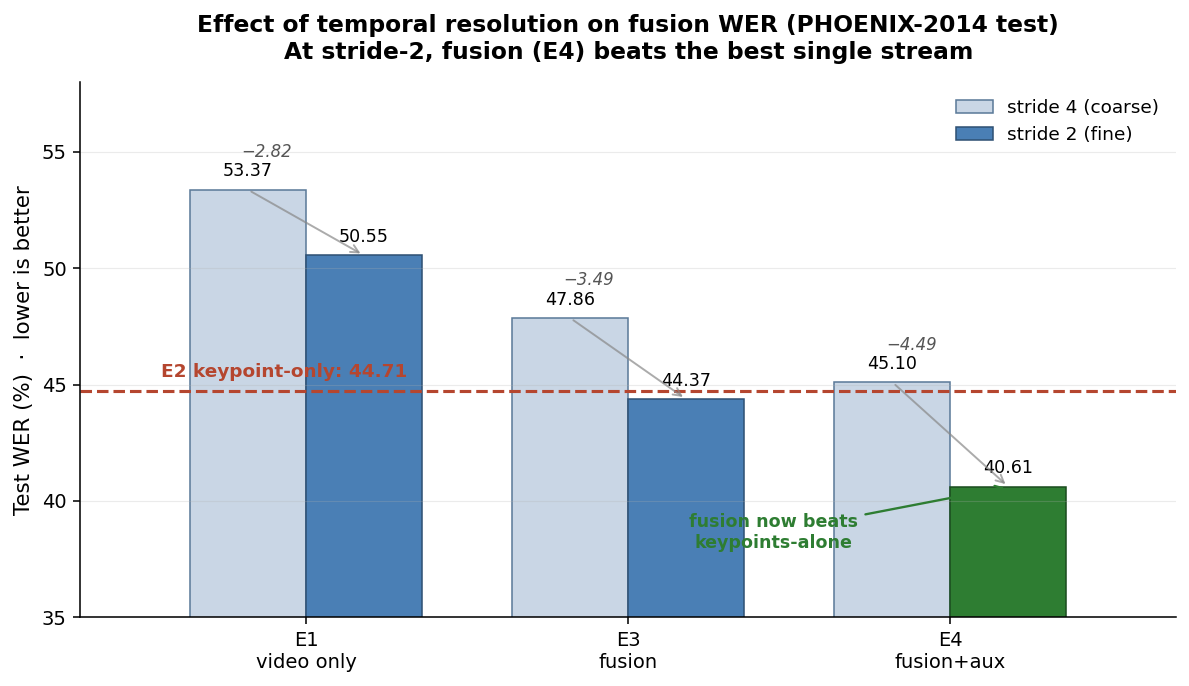

saved: /content/drive/MyDrive/sign_project/runs/resolution_study.png


In [29]:
# Stage 10.6 — Resolution-study chart: stride-4 vs stride-2 WER across E1/E3/E4 with the E2 reference line.
import matplotlib.pyplot as plt
import numpy as np, os

labels   = ['E1\nvideo only', 'E3\nfusion', 'E4\nfusion+aux']
stride4  = [53.37, 47.86, 45.10]
stride2  = [50.55, 44.37, 40.61]
E2_BAR   = 44.71

x = np.arange(len(labels)); w = 0.36
fig, ax = plt.subplots(figsize=(8.6, 5.0), dpi=140)

b1 = ax.bar(x - w/2, stride4, w, label='stride 4 (coarse)',
            color='#c9d6e5', edgecolor='#5b7a99', linewidth=0.8)
b2 = ax.bar(x + w/2, stride2, w, label='stride 2 (fine)',
            color='#4a7fb5', edgecolor='#2f5174', linewidth=0.8)

# E2 reference line — label moved to LEFT side to avoid the -4.49
ax.axhline(E2_BAR, color='#b5462f', lw=1.6, ls='--', zorder=1)
ax.text(-0.45, E2_BAR + 0.45, f'E2 keypoint-only: {E2_BAR:.2f}',
        color='#b5462f', fontsize=9.5, ha='left', va='bottom', fontweight='bold')

for bars in (b1, b2):
    for r in bars:
        h = r.get_height()
        ax.text(r.get_x()+r.get_width()/2, h+0.4, f'{h:.2f}', ha='center', va='bottom', fontsize=9)

b2[2].set_color('#2e7d32'); b2[2].set_edgecolor('#1b4d1f')

# improvement arrows + drop labels (nudged up a bit so they clear the line)
for i in range(len(labels)):
    ax.annotate('', xy=(x[i]+w/2, stride2[i]), xytext=(x[i]-w/2, stride4[i]),
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.0, alpha=0.7))
    drop = stride4[i]-stride2[i]
    ax.text(x[i]-w/2-0.02, stride4[i]+1.4, f'−{drop:.2f}',
            ha='left', fontsize=8.5, color='#555', style='italic')

ax.set_ylabel('Test WER (%)  ·  lower is better', fontsize=11)
ax.set_title('Effect of temporal resolution on fusion WER (PHOENIX-2014 test)\n'
             'At stride-2, fusion (E4) beats the best single stream',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(35, 58); ax.set_xlim(-0.7, 2.7)
ax.legend(loc='upper right', frameon=False, fontsize=9.5)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.25, lw=0.6)

# green win annotation — repositioned to sit left of the green bar, fully inside
ax.annotate('fusion now beats\nkeypoints-alone',
            xy=(x[2]+w/2, 40.61), xytext=(x[2]-0.55, 38.0),
            fontsize=9, color='#2e7d32', fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='#2e7d32', lw=1.2))

plt.tight_layout()
out_path = os.path.join(cfg['paths']['runs'], 'resolution_study.png')
plt.savefig(out_path, bbox_inches='tight', dpi=140)
plt.show()
print("saved:", out_path)